This code block generates a synthetic dataset for classification using `make_classification` from `sklearn.datasets`. It creates 100 samples with 2 features, 1 informative feature, 0 redundant features, 2 classes, and 1 cluster per class.

In [5]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

This code block imports the `matplotlib.pyplot` library for plotting, commonly aliased as `plt`.

In [6]:
import matplotlib.pyplot as plt

This code block creates a scatter plot of the generated dataset. It sets the figure size, plots the two features (`X[:,0]` and `X[:,1]`), colors the points based on their class (`c=y`), uses the 'winter' colormap, and sets the marker size to 100.

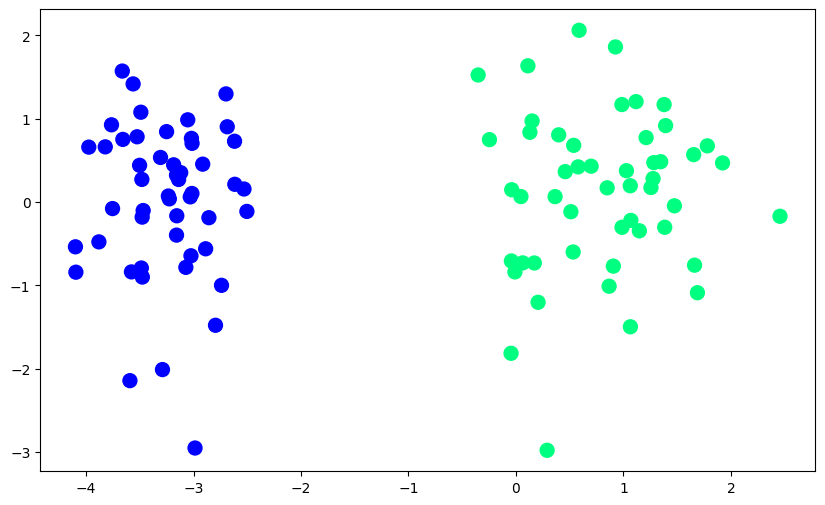

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

This code block imports the `LogisticRegression` model from `sklearn.linear_model`. It then initializes the model with the 'sag' solver and fits the model to the generated data (`X`, `y`).

In [8]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(solver='sag')
lor.fit(X,y)

LogisticRegression(solver='sag')

This code block prints the coefficients (`lor.coef_`) and the intercept (`lor.intercept_`) learned by the Logistic Regression model.

In [9]:
print(lor.coef_)
print(lor.intercept_)

[[2.36516442 0.02173924]]
[3.13177321]


This code block calculates the slope (`m1`) and y-intercept (`b1`) of the decision boundary derived from the Logistic Regression model's coefficients and intercept. These values are used to define the line representing the decision boundary.

In [10]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

This code block generates a range of x-values (`x_input`) from -3 to 3 to plot the decision boundary. It then calculates the corresponding y-values (`y_input`) using the slope and intercept (`m1`, `b1`) obtained from the Logistic Regression model.

In [11]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

This code block defines a function `gd` (gradient descent) to implement logistic regression from scratch. It adds a bias term to `X`, initializes weights, sets a learning rate, and iteratively updates the weights using the gradient descent algorithm for 5000 iterations. It returns the learned coefficients and intercept.

In [12]:
def gd(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5

    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])

    return weights[1:],weights[0]


This code block defines the sigmoid activation function, which is crucial for logistic regression. It takes an input `z` and returns `1 / (1 + exp(-z))`.

In [13]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

This code block calls the custom `gd` function with the dataset `X` and labels `y` to train a logistic regression model using gradient descent. It stores the returned coefficients and intercept in `coef_` and `intercept_` respectively.

In [14]:
coef_,intercept_ = gd(X,y)

This code block calculates the slope (`m`) and y-intercept (`b`) of the decision boundary using the coefficients (`coef_`) and intercept (`intercept_`) obtained from the custom gradient descent implementation.

In [15]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

This code block generates a range of x-values (`x_input1`) from -3 to 3 for plotting. It then calculates the corresponding y-values (`y_input1`) using the slope and intercept (`m`, `b`) from the custom gradient descent model, representing its decision boundary.

In [16]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

This code block generates a final plot comparing the decision boundaries of both logistic regression models. It displays the original scatter plot of the data, the decision boundary from `sklearn.linear_model.LogisticRegression` (red line), and the decision boundary from the custom gradient descent implementation (black line). It also sets the y-axis limits.

(-3.0, 2.0)

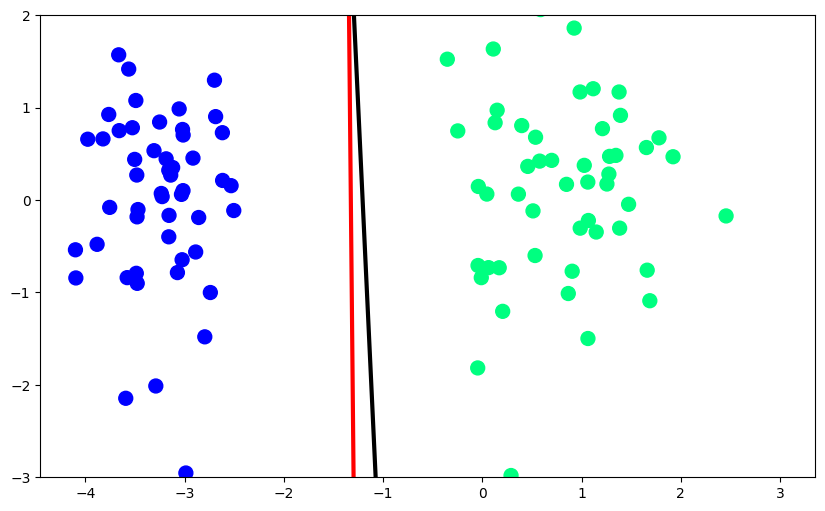

In [17]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)